# 🐶🐱 Cats vs Dogs Classification – Complete Teaching Demo
## HOG vs CNN Features + SVM + Visualizations

This notebook demonstrates:
- HOG feature extraction + visualization
- CNN (ResNet18) feature extraction
- Grad-CAM visualization
- Saving features to CSV
- SVM training
- Confusion matrix
- ROC curve
- Performance comparison


In [1]:
import os
import gc
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
ImageFile.LOAD_TRUNCATED_IMAGES = True
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print('Imports loaded successfully.')

Imports loaded successfully.


In [ ]:
## Dataset Structure
```
dataset/
   cats/
   dogs/
```

In [2]:
from pathlib import Path

USER_GIVEN_PATH = Path('/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset')

def looks_like_class_root(path: Path) -> bool:
    if not path.exists() or not path.is_dir():
        return False
    child_dirs = [x for x in path.iterdir() if x.is_dir()]
    child_names = {x.name.lower() for x in child_dirs}
    return (
        {'cat', 'dog'}.issubset(child_names) or
        {'cats', 'dogs'}.issubset(child_names)
    )

def find_dataset_dir():
    candidate_paths = [
        USER_GIVEN_PATH,
        Path('/kaggle/input/dog-and-cat-classification-dataset'),
        Path('/kaggle/input/bhavikjikadara/dog-and-cat-classification-dataset'),
        Path('/kaggle/input/cats-and-dogs-classification-dataset'),
        Path('/kaggle/input/microsoft-catsvsdogs-dataset'),
        Path('/kaggle/input/cats-vs-dogs'),
        Path('/kaggle/input'),
    ]

    for base in candidate_paths:
        if not base.exists():
            continue

        if looks_like_class_root(base):
            return base

        for p in base.rglob('*'):
            try:
                if looks_like_class_root(p):
                    return p
            except Exception:
                continue

    raise FileNotFoundError(
        'Dataset folder not found. In Kaggle, attach the dataset first.'
    )

def get_class_dirs(root_dir):
    class_dirs = [d for d in Path(root_dir).iterdir() if d.is_dir()]
    preferred = [d for d in class_dirs if d.name.lower() in {'cat', 'cats', 'dog', 'dogs'}]
    class_dirs = sorted(preferred or class_dirs, key=lambda x: x.name.lower())

    if len(class_dirs) < 2:
        raise ValueError('Could not find both Cat and Dog folders.')

    return class_dirs

data_dir = find_dataset_dir()
class_dirs = get_class_dirs(data_dir)
output_dir = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('.')
output_dir.mkdir(parents=True, exist_ok=True)

MAX_IMAGES_PER_CLASS = 500
IMG_SIZE_HOG = (64, 64)
BATCH_SIZE = 32
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

print('User given path:', USER_GIVEN_PATH)
print('Detected dataset folder:', data_dir)
print('Class folders:', [d.name for d in class_dirs])
print('Output folder:', output_dir)


User given path: /kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset
Detected dataset folder: /kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages
Class folders: ['Cat', 'Dog']
Output folder: /kaggle/working


In [3]:
sampled_items = []
class_counts = {}

for class_dir in class_dirs:
    files = [
        p for p in sorted(class_dir.iterdir())
        if p.is_file() and p.suffix.lower() in VALID_EXTS
    ]
    class_counts[class_dir.name] = len(files)
    sampled_items.extend((p, class_dir.name) for p in files[:MAX_IMAGES_PER_CLASS])

print('All image files per class:', class_counts)
print('Selected images for this demo:', len(sampled_items))

if len(sampled_items) == 0:
    raise ValueError('No image files were found in the detected dataset folder.')


All image files per class: {'Cat': 12499, 'Dog': 12499}
Selected images for this demo: 1000


## 2. HOG feature extraction + visualization

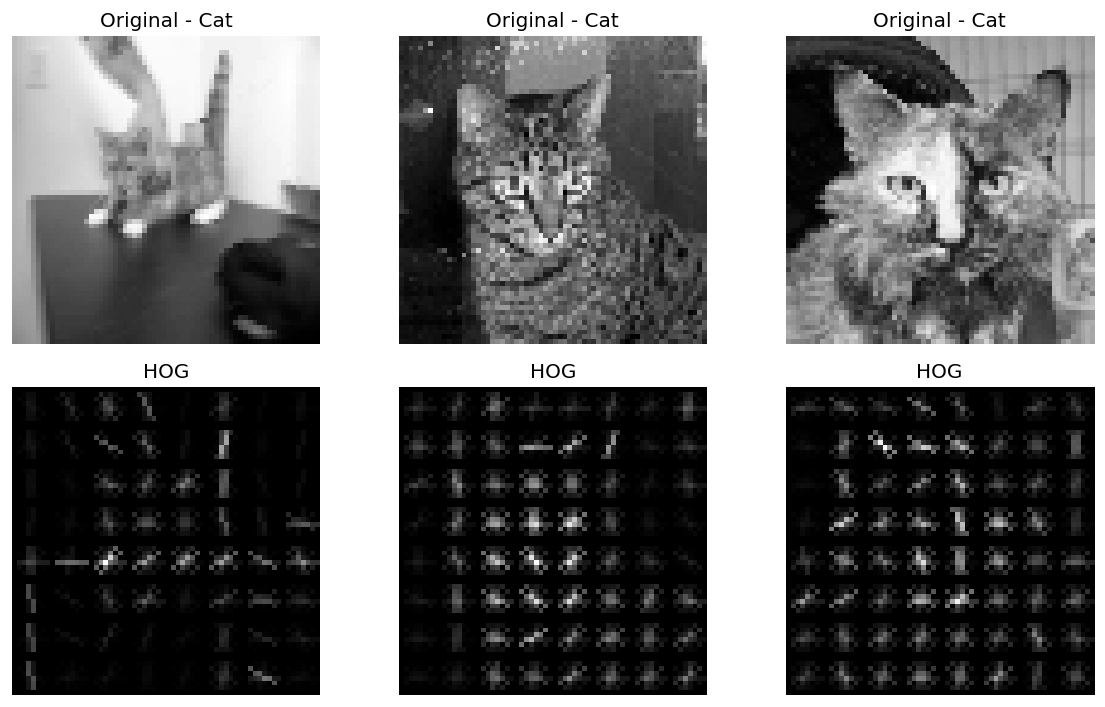

Valid HOG images: 999
Skipped bad images: 1


In [4]:
hog_features = []
hog_labels = []
shown = 0
bad_images = 0

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for ax in axes.ravel():
    ax.axis('off')

for img_path, label in sampled_items:
    try:
        img = cv2.imread(str(img_path))
        if img is None:
            bad_images += 1
            continue

        img = cv2.resize(img, IMG_SIZE_HOG)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        if shown < 3:
            features, hog_img = hog(
                gray,
                orientations=9,
                pixels_per_cell=(8, 8),
                cells_per_block=(2, 2),
                visualize=True,
                feature_vector=True,
            )

            axes[0, shown].imshow(gray, cmap='gray')
            axes[0, shown].set_title(f'Original - {label}')
            axes[0, shown].axis('off')

            axes[1, shown].imshow(hog_img, cmap='gray')
            axes[1, shown].set_title('HOG')
            axes[1, shown].axis('off')
            shown += 1
        else:
            features = hog(
                gray,
                orientations=9,
                pixels_per_cell=(8, 8),
                cells_per_block=(2, 2),
                visualize=False,
                feature_vector=True,
            )

        hog_features.append(features.astype(np.float32))
        hog_labels.append(label)

    except Exception:
        bad_images += 1
        continue

plt.tight_layout()
plt.show()

if len(hog_features) == 0:
    raise ValueError('No valid images were found for HOG feature extraction.')

print('Valid HOG images:', len(hog_features))
print('Skipped bad images:', bad_images)


In [5]:
X_hog = np.vstack(hog_features)
y_hog = np.array(hog_labels)

hog_df = pd.DataFrame(X_hog)
hog_df['label'] = y_hog
hog_csv_path = output_dir / 'hog_features.csv'
hog_df.to_csv(hog_csv_path, index=False)

print('HOG feature shape:', X_hog.shape)
print('Saved HOG CSV:', hog_csv_path)
hog_df.head()

HOG feature shape: (999, 1764)
Saved HOG CSV: /kaggle/working/hog_features.csv


,0,1,2,3,4,5,6,7,8,9,...,1755,1756,1757,1758,1759,1760,1761,1762,1763,label
0,0.299716,0.105944,0.000000,0.039163,0.029146,0.187086,0.043002,0.175882,0.299716,0.299716,...,0.070281,0.011604,0.080773,0.084281,0.119587,0.058136,0.033078,0.020980,0.028181,Cat
1,0.247851,0.019764,0.098693,0.081281,0.251970,0.053492,0.021691,0.025628,0.192031,0.257132,...,0.233647,0.233647,0.119587,0.233647,0.197381,0.068730,0.067547,0.018326,0.147568,Cat
2,0.077002,0.062092,0.123761,0.215167,0.290241,0.141815,0.031287,0.016792,0.029713,0.029493,...,0.264545,0.138034,0.109356,0.133801,0.088421,0.264545,0.023506,0.174513,0.105286,Cat
3,0.085851,0.021158,0.035594,0.059880,0.103740,0.049666,0.026164,0.050522,0.054682,0.149485,...,0.309021,0.055474,0.027219,0.012856,0.008355,0.000000,0.003376,0.128484,0.309021,Cat
4,0.231729,0.140815,0.026988,0.122953,0.142030,0.078703,0.231729,0.162550,0.157862,0.231729,...,0.233501,0.061374,0.217880,0.065811,0.179895,0.034572,0.090267,0.083249,0.119094,Cat


## 3. Train Linear SVM on HOG features

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_hog, y_hog, test_size=0.2, random_state=42, stratify=y_hog
)

svm_hog = make_pipeline(
    StandardScaler(),
    LinearSVC(max_iter=10000, random_state=42)
)

svm_hog.fit(X_train, y_train)
y_pred = svm_hog.predict(X_test)
hog_accuracy = accuracy_score(y_test, y_pred)

print('HOG Accuracy:', round(hog_accuracy, 4))
print(classification_report(y_test, y_pred, zero_division=0))

HOG Accuracy: 0.59
              precision    recall  f1-score   support

         Cat       0.60      0.54      0.57       100
         Dog       0.58      0.64      0.61       100

    accuracy                           0.59       200
   macro avg       0.59      0.59      0.59       200
weighted avg       0.59      0.59      0.59       200



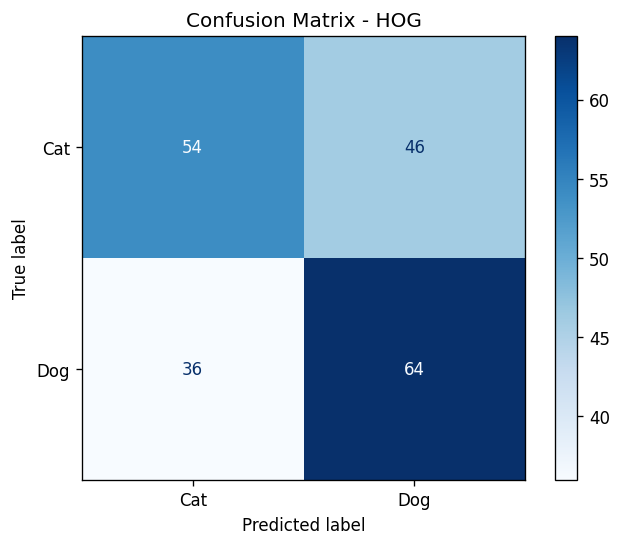

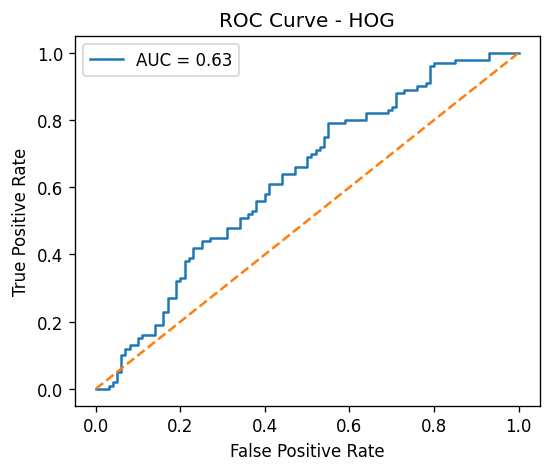

In [7]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Confusion Matrix - HOG')
plt.show()

positive_label = None
for candidate in ['dogs', 'dog', 'Dog', 'Dogs']:
    if candidate in set(y_test):
        positive_label = candidate
        break
if positive_label is None:
    positive_label = sorted(set(y_test))[-1]

scores = svm_hog.decision_function(X_test)
y_true_binary = (y_test == positive_label).astype(int)
fpr, tpr, _ = roc_curve(y_true_binary, scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - HOG')
plt.legend()
plt.show()

## 4. CNN feature extraction (ResNet18)

In [8]:
use_resnet18 = False

try:
    import torchvision.models as models
    import torchvision.transforms as T

    weights = models.ResNet18_Weights.DEFAULT
    backbone = models.resnet18(weights=weights)
    cnn_transform = weights.transforms()
    feature_extractor = torch.nn.Sequential(*list(backbone.children())[:-1])
    use_resnet18 = True
    print('Loaded pretrained ResNet18 weights.')
except Exception as e:
    print(f'ResNet18 is not available in this session ({e}). Using a small fallback CNN instead.')

    class SmallCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
                nn.ReLU(),
                nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
                nn.ReLU(),
                nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
                nn.ReLU(),
                nn.AdaptiveAvgPool2d((1, 1)),
            )

        def forward(self, x):
            x = self.features(x)
            return x.flatten(1)

    feature_extractor = SmallCNN()
    cnn_transform = None

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

cnn_items = []
for img_path, label in sampled_items:
    try:
        with Image.open(img_path) as img:
            img = img.convert('RGB')
        cnn_items.append((img_path, label))
    except Exception:
        continue

if len(cnn_items) == 0:
    raise ValueError('No valid images were found for CNN feature extraction.')

class SafeImageDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label = self.items[idx]
        with Image.open(path) as img:
            img = img.convert('RGB')

        if self.transform is not None:
            img = self.transform(img)
        else:
            img = img.resize((64, 64))
            arr = np.asarray(img, dtype=np.float32) / 255.0
            img = torch.from_numpy(arr).permute(2, 0, 1)

        return img, label

cnn_dataset = SafeImageDataset(cnn_items, cnn_transform)
cnn_loader = DataLoader(cnn_dataset, batch_size=BATCH_SIZE, shuffle=False)

cnn_features = []
cnn_labels = []

with torch.no_grad():
    for imgs, labels in cnn_loader:
        imgs = imgs.to(device)
        outputs = feature_extractor(imgs)
        outputs = outputs.flatten(1).cpu().numpy().astype(np.float32)
        cnn_features.append(outputs)
        cnn_labels.extend(list(labels))

X_cnn = np.vstack(cnn_features)
y_cnn = np.array(cnn_labels)

print('CNN feature shape:', X_cnn.shape)
print('Feature extractor:', 'ResNet18' if use_resnet18 else 'SmallCNN fallback')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
ResNet18 is not available in this session (<urlopen error [Errno -3] Temporary failure in name resolution>). Using a small fallback CNN instead.
CNN feature shape: (1000, 64)
Feature extractor: SmallCNN fallback


In [15]:
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn, y_cnn, test_size=0.2, random_state=42, stratify=y_cnn
)

svm_cnn = make_pipeline(
    StandardScaler(),
    LinearSVC(max_iter=10000, random_state=42)
)

svm_cnn.fit(X_train_cnn, y_train_cnn)
y_pred_cnn = svm_cnn.predict(X_test_cnn)
cnn_accuracy = accuracy_score(y_test_cnn, y_pred_cnn)

print('CNN Feature Accuracy:', round(cnn_accuracy, 4))
print(classification_report(y_test_cnn, y_pred_cnn, zero_division=0))

CNN Feature Accuracy: 0.605
              precision    recall  f1-score   support

         Cat       0.60      0.63      0.61       100
         Dog       0.61      0.58      0.59       100

    accuracy                           0.60       200
   macro avg       0.61      0.60      0.60       200
weighted avg       0.61      0.60      0.60       200



## 5. Final comparison

If you want to use the full dataset later, increase:

`MAX_IMAGES_PER_CLASS = 500`

to a bigger number.


In [19]:
print('HOG Accuracy:', round(hog_accuracy, 4))
print('CNN Accuracy:', round(cnn_accuracy, 4))

HOG Accuracy: 0.59
CNN Accuracy: 0.605
